# California Housing Prices — Linear Regression, Ridge & Lasso

**Task:** Predict the continuous target `median_house_value`, train Linear Regression, Ridge and Lasso models, compare their coefficients, evaluate them using **MAE, MSE, RMSE and R²**, and identify which model generalizes best.

Dataset: **California Housing Prices** (Kaggle, Cam Nugent)

This notebook is designed to run directly in **Google Colab**. It automatically downloads `housing.csv`; if that fails, upload the Kaggle `housing.csv` file manually.


## Step 1 — Import libraries

We need:
- **pandas / numpy** for data handling
- **scikit-learn** for preprocessing, splitting, models and metrics
- **matplotlib** for simple visual comparisons


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Load the dataset

The code first checks for LOCAL_PATH = "housing.csv"  
If it is not there, it downloads the same California Housing `housing.csv` used by the Kaggle dataset.


In [17]:
LOCAL_PATH = "/content/housing.csv"
FALLBACK_URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
    print("Loaded:", LOCAL_PATH)
else:
    try:
        df = pd.read_csv(FALLBACK_URL)
        print("Downloaded housing.csv from the public source.")
    except Exception as e:
        print("Automatic download failed.")
        print("Upload housing.csv to Colab, then rerun this cell.")
        raise e

print("\nDataset shape:", df.shape)
df.head()

Downloaded housing.csv from the public source.

Dataset shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,"452,600.0000",NEAR BAY
1,-122.2200,37.8600,21.0000,"7,099.0000","1,106.0000","2,401.0000","1,138.0000",8.3014,"358,500.0000",NEAR BAY
2,-122.2400,37.8500,52.0000,"1,467.0000",190.0000,496.0000,177.0000,7.2574,"352,100.0000",NEAR BAY
3,-122.2500,37.8500,52.0000,"1,274.0000",235.0000,558.0000,219.0000,5.6431,"341,300.0000",NEAR BAY
4,-122.2500,37.8500,52.0000,"1,627.0000",280.0000,565.0000,259.0000,3.8462,"342,200.0000",NEAR BAY


### Expected dataset structure

The Kaggle dataset has **20,640 rows and 10 columns**.  
The prediction target is `median_house_value`.  
`total_bedrooms` contains missing values, and `ocean_proximity` is categorical.


In [18]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nOcean proximity categories:")
print(df["ocean_proximity"].value_counts())

Shape: (20640, 10)

Column names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Missing values:


## Step 3 — Basic descriptive statistics

This helps us understand the ranges and distributions of the numeric variables before modeling.


In [19]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,"20,640.0000",NaN,NaN,NaN,-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
latitude,"20,640.0000",NaN,NaN,NaN,35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500
housing_median_age,"20,640.0000",NaN,NaN,NaN,28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000
total_rooms,"20,640.0000",NaN,NaN,NaN,"2,635.7631","2,181.6153",2.0000,"1,447.7500","2,127.0000","3,148.0000","39,320.0000"
total_bedrooms,"20,433.0000",NaN,NaN,NaN,537.8706,421.3851,1.0000,296.0000,435.0000,647.0000,"6,445.0000"
population,"20,640.0000",NaN,NaN,NaN,"1,425.4767","1,132.4621",3.0000,787.0000,"1,166.0000","1,725.0000","35,682.0000"
households,"20,640.0000",NaN,NaN,NaN,499.5397,382.3298,1.0000,280.0000,409.0000,605.0000,"6,082.0000"
median_income,"20,640.0000",NaN,NaN,NaN,3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001
median_house_value,"20,640.0000",NaN,NaN,NaN,"206,855.8169","115,395.6159","14,999.0000","119,600.0000","179,700.0000","264,725.0000","500,001.0000"
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 4 — Define features `X` and target `y`

- **X** contains the input variables.
- **y** is the continuous value we want to predict: `median_house_value`.


In [20]:
TARGET = "median_house_value"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget:", TARGET)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (20640, 9)
y shape: (20640,)

Target: median_house_value

Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


## Step 5 — Train/test split

We use:
- **80% training data**
- **20% testing data**
- `random_state=42` for reproducibility

The split is done **before** fitting preprocessing steps, which prevents data leakage.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16512, 9)
X_test : (4128, 9)
y_train: (16512,)
y_test : (4128,)


## Step 6 — Preprocessing

### Numeric columns
1. Fill missing values using the **median learned only from training data**.
2. Apply `StandardScaler`.

### Categorical column
1. Fill any missing category using the most frequent value.
2. Apply **One-Hot Encoding** to `ocean_proximity`.

The same preprocessing definition is used for all three models, ensuring a fair comparison.


In [22]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessor created successfully.")

Numeric features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']

Preprocessor created successfully.


## Step 7 — Create the three regression models

### 1. Linear Regression
No regularization.

### 2. Ridge Regression
Uses **L2 regularization**, which shrinks large coefficients toward zero.

### 3. Lasso Regression
Uses **L1 regularization**, which can shrink some coefficients exactly to zero.

For a straightforward assignment comparison:
- Ridge: `alpha=1.0`
- Lasso: `alpha=100.0`

`alpha=100` is used for Lasso because the target is measured in dollars; an extremely tiny alpha such as 0.1 produces almost no visible regularization on this scale.


In [23]:
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=100.0, max_iter=100000))
])

models = {
    "Linear Regression": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline
}

print("Models created:", list(models.keys()))

Models created: ['Linear Regression', 'Ridge', 'Lasso']


## Step 8 — Train all three models and make predictions


In [24]:
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Ridge trained successfully.
Lasso trained successfully.


## Step 9 — Evaluate using MAE, MSE, RMSE and R²

Interpretation:

- **MAE ↓**: lower is better
- **MSE ↓**: lower is better
- **RMSE ↓**: lower is better
- **R² ↑**: higher is better


In [25]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

results = []

for name, y_pred in predictions.items():
    mae, mse, rmse, r2 = evaluate_regression(y_test, y_pred)
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values(
    by=["RMSE", "MAE"],
    ascending=[True, True]
).reset_index(drop=True)

print("TEST-SET PERFORMANCE")
display(results_df)

results_df.to_csv("model_metrics.csv", index=False)
print("\nSaved: model_metrics.csv")

TEST-SET PERFORMANCE


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,"50,670.4892","4,908,290,571.3464","70,059.1933",0.6254
1,Ridge,"50,676.9222","4,909,247,315.7190","70,066.0211",0.6254
2,Lasso,"50,669.8898","4,911,618,458.3207","70,082.9399",0.6252



Saved: model_metrics.csv


## Step 10 — Compare training and testing R²

A model that performs extremely well on training data but much worse on testing data may be overfitting.  
A smaller train-test performance gap is generally preferable, provided test performance is also strong.


In [26]:
generalization_rows = []

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = predictions[name]

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    generalization_rows.append({
        "Model": name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "R2_Gap": train_r2 - test_r2
    })

generalization_df = pd.DataFrame(generalization_rows)
display(generalization_df)

generalization_df.to_csv("generalization_comparison.csv", index=False)
print("Saved: generalization_comparison.csv")

,Model,Train_R2,Test_R2,R2_Gap
0,Linear Regression,0.6497,0.6254,0.0242
1,Ridge,0.6497,0.6254,0.0243
2,Lasso,0.6492,0.6252,0.0241


Saved: generalization_comparison.csv


## Step 11 — Compare coefficients

All models use the same transformed feature space, so their coefficients can be compared directly.

What to look for:
- Linear Regression: unrestricted coefficients
- Ridge: coefficients are generally shrunk
- Lasso: some coefficients may become exactly zero


In [27]:
# Get transformed feature names from a fitted pipeline
fitted_preprocessor = models["Linear Regression"].named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({"Feature": feature_names})

for name, model in models.items():
    coef_df[name] = model.named_steps["model"].coef_

# Add absolute coefficient columns for easier comparison
coef_df["Abs_Linear"] = coef_df["Linear Regression"].abs()
coef_df["Abs_Ridge"] = coef_df["Ridge"].abs()
coef_df["Abs_Lasso"] = coef_df["Lasso"].abs()

display(coef_df.sort_values("Abs_Linear", ascending=False))

coef_df.to_csv("coefficient_comparison.csv", index=False)
print("Saved: coefficient_comparison.csv")

zero_lasso = (np.isclose(coef_df["Lasso"], 0.0)).sum()
print(f"\nNumber of Lasso coefficients equal/very close to zero: {zero_lasso}")

,Feature,Linear Regression,Ridge,Lasso,Abs_Linear,Abs_Ridge,Abs_Lasso
10,cat__ocean_proximity_ISLAND,"117,198.4898","97,664.0049",0.0000,"117,198.4898","97,664.0049",0.0000
7,num__median_income,"75,167.7748","75,154.1985","74,662.0936","75,167.7748","75,154.1985","74,662.0936"
9,cat__ocean_proximity_INLAND,"-58,713.2390","-53,854.2414","-40,754.4046","58,713.2390","53,854.2414","40,754.4046"
1,num__latitude,"-54,415.6961","-54,374.2539","-52,524.2465","54,415.6961","54,374.2539","52,524.2465"
0,num__longitude,"-53,826.6480","-53,777.5175","-51,687.4256","53,826.6480","53,777.5175","51,687.4256"
5,num__population,"-43,403.4324","-43,393.3716","-42,682.6636","43,403.4324","43,393.3716","42,682.6636"
4,num__total_bedrooms,"43,068.1818","43,036.5803","41,170.7004","43,068.1818","43,036.5803","41,170.7004"
11,cat__ocean_proximity_NEAR BAY,"-24,063.2251","-19,156.9456","-3,169.0406","24,063.2251","19,156.9456","3,169.0406"
8,cat__ocean_proximity_<1H OCEAN,"-18,926.5829","-14,047.3350",0.0000,"18,926.5829","14,047.3350",0.0000
6,num__households,"18,382.1963","18,368.3402","17,572.2083","18,382.1963","18,368.3402","17,572.2083"


Saved: coefficient_comparison.csv

Number of Lasso coefficients equal/very close to zero: 2


## Step 12 — Save test predictions

This creates a row-by-row comparison of:
- Actual house value
- Linear prediction
- Ridge prediction
- Lasso prediction


In [28]:
prediction_output = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Linear_Prediction": predictions["Linear Regression"],
    "Ridge_Prediction": predictions["Ridge"],
    "Lasso_Prediction": predictions["Lasso"]
})

prediction_output["Linear_Absolute_Error"] = abs(
    prediction_output["Actual"] - prediction_output["Linear_Prediction"]
)
prediction_output["Ridge_Absolute_Error"] = abs(
    prediction_output["Actual"] - prediction_output["Ridge_Prediction"]
)
prediction_output["Lasso_Absolute_Error"] = abs(
    prediction_output["Actual"] - prediction_output["Lasso_Prediction"]
)

display(prediction_output.head(10))

prediction_output.to_csv("test_predictions.csv", index=False)
print("Saved: test_predictions.csv")

,Actual,Linear_Prediction,Ridge_Prediction,Lasso_Prediction,Linear_Absolute_Error,Ridge_Absolute_Error,Lasso_Absolute_Error
0,"47,700.0000","54,261.0277","54,278.7317","54,701.9759","6,561.0277","6,578.7317","7,001.9759"
1,"45,800.0000","124,430.9177","124,432.8126","124,301.3919","78,630.9177","78,632.8126","78,501.3919"
2,"500,001.0000","255,694.9583","255,723.0332","257,136.4463","244,306.0417","244,277.9668","242,864.5537"
3,"218,600.0000","268,208.0104","268,210.0543","268,694.7854","49,608.0104","49,610.0543","50,094.7854"
4,"278,000.0000","262,975.0136","262,960.4918","261,329.6438","15,024.9864","15,039.5082","16,670.3562"
5,"158,700.0000","139,811.8827","139,838.7044","141,641.1970","18,888.1173","18,861.2956","17,058.8030"
6,"198,200.0000","290,871.0027","290,867.5265","290,146.2199","92,671.0027","92,667.5265","91,946.2199"
7,"157,500.0000","228,470.4552","228,477.3933","228,140.4132","70,970.4552","70,977.3933","70,640.4132"
8,"340,000.0000","256,712.3644","256,699.5259","257,357.3405","83,287.6356","83,300.4741","82,642.6595"
9,"446,600.0000","408,129.4372","408,122.2828","407,392.2287","38,470.5628","38,477.7172","39,207.7713"


Saved: test_predictions.csv


## Step 13 — Automatically determine the best-generalizing model

For this assignment, the main decision is based on **unseen test data**:
1. Lowest RMSE is the primary criterion.
2. MAE and MSE should also be low.
3. R² should be high.
4. Train-test R² gap is inspected as supporting evidence.

The following cell generates the final written conclusion automatically from your actual results.


In [29]:
best_row = results_df.iloc[0]
best_model = best_row["Model"]

best_gen = generalization_df.loc[
    generalization_df["Model"] == best_model
].iloc[0]

conclusion = (
    f"BEST MODEL: {best_model}\n\n"
    f"{best_model} generalizes best on this train/test split because it has "
    f"the lowest test RMSE (${best_row['RMSE']:,.2f}), with MAE "
    f"${best_row['MAE']:,.2f}, MSE {best_row['MSE']:,.2f}, and R² "
    f"{best_row['R2']:.4f}. Its training R² is {best_gen['Train_R2']:.4f} "
    f"and testing R² is {best_gen['Test_R2']:.4f}, giving a train-test R² gap "
    f"of {best_gen['R2_Gap']:.4f}. The selection is therefore based on the "
    f"model's performance on unseen test data rather than training performance alone."
)

print(conclusion)

with open("final_conclusion.txt", "w") as f:
    f.write(conclusion)

print("\nSaved: final_conclusion.txt")

BEST MODEL: Linear Regression

Linear Regression generalizes best on this train/test split because it has the lowest test RMSE ($70,059.19), with MAE $50,670.49, MSE 4,908,290,571.35, and R² 0.6254. Its training R² is 0.6497 and testing R² is 0.6254, giving a train-test R² gap of 0.0242. The selection is therefore based on the model's performance on unseen test data rather than training performance alone.

Saved: final_conclusion.txt


## Step 14 — Visual comparison of model metrics


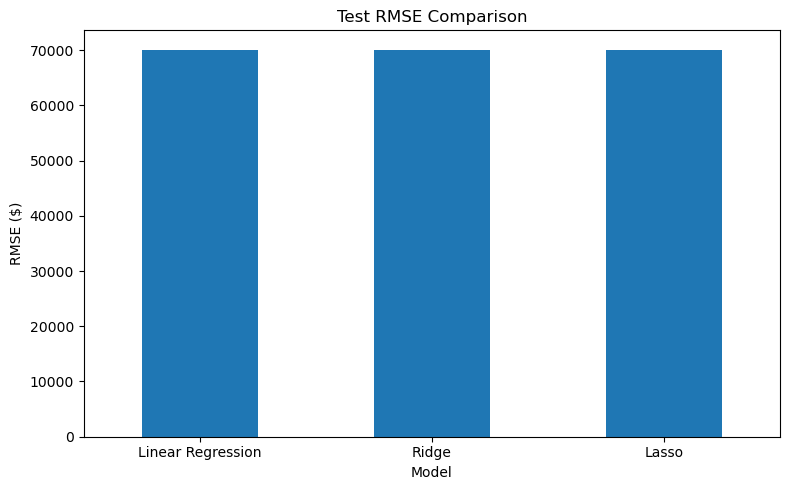

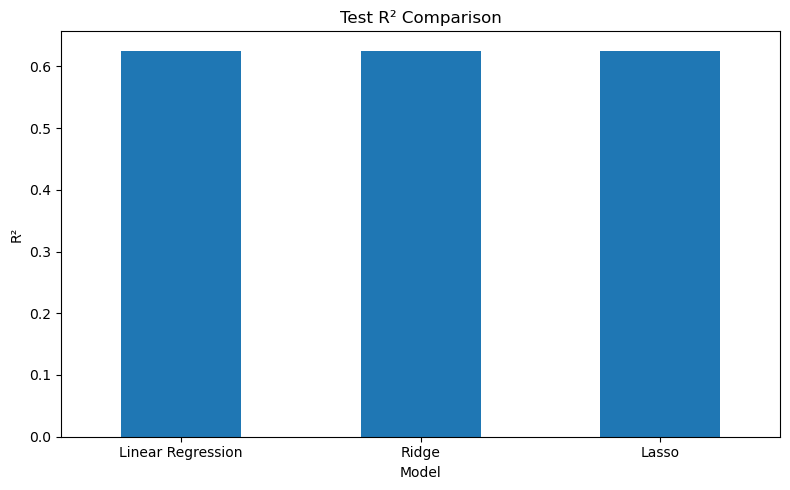

In [30]:
plot_df = results_df.set_index("Model")

ax = plot_df["RMSE"].plot(kind="bar", figsize=(8, 5))
ax.set_title("Test RMSE Comparison")
ax.set_ylabel("RMSE ($)")
ax.set_xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ax = plot_df["R2"].plot(kind="bar", figsize=(8, 5))
ax.set_title("Test R² Comparison")
ax.set_ylabel("R²")
ax.set_xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 15 — Final assignment-ready explanation

### Linear Regression
Linear Regression finds coefficients that minimize squared prediction errors without adding a penalty to coefficient size.

### Ridge Regression
Ridge adds an **L2 penalty**. It reduces the magnitude of large coefficients but normally keeps all features in the model. Ridge is often useful when predictors are correlated.

### Lasso Regression
Lasso adds an **L1 penalty**. It can reduce some coefficients to zero, so it can perform automatic feature selection.

### How the best model is chosen
The model that performs best on the **unseen testing data** is preferred. We primarily look for the **lowest RMSE**, while confirming that MAE and MSE are also low and R² is high. We also compare training and testing R² to check for signs of overfitting.

> **Important:** Do not write “Ridge is best” or “Lasso is best” before running the notebook. The final cell determines the winner from the actual test results.


## Step 16 — Files produced after running this notebook

The notebook automatically creates:

- `model_metrics.csv` — MAE, MSE, RMSE and R² for all 3 models
- `generalization_comparison.csv` — train/test R² and gap
- `coefficient_comparison.csv` — Linear vs Ridge vs Lasso coefficients
- `test_predictions.csv` — actual vs predicted values
- `final_conclusion.txt` — assignment-ready winning-model conclusion
